### Objective
Perform Exploratory Data Analysis (EDA) on Mutual Fund datasets using Python, Pandas, Seaborn, Matplotlib, and Plotly.

In [63]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [64]:
# LOAD CLEANED DATASETS

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print("All cleaned datasets loaded successfully.")

All cleaned datasets loaded successfully.


In [65]:
# DATASET SHAPES

print("Fund Master :", fund_master.shape)
print("NAV History :", nav_history.shape)
print("AUM :", aum.shape)
print("SIP :", sip.shape)
print("Category :", category.shape)
print("Folio :", folio.shape)
print("Performance :", performance.shape)
print("Transactions :", transactions.shape)
print("Portfolio :", portfolio.shape)
print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
AUM : (90, 5)
SIP : (48, 6)
Category : (144, 3)
Folio : (21, 6)
Performance : (40, 19)
Transactions : (32778, 13)
Portfolio : (322, 8)
Benchmark : (8050, 3)


In [66]:
# DISPLAY FIRST 5 ROWS

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [67]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [68]:
nav_history.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Dataset Overview

The cleaned datasets were loaded successfully from the `data/processed` folder. These datasets include fund information, NAV history, AUM, SIP inflows, category inflows, folio counts, investor transactions, portfolio holdings, performance metrics, and benchmark indices. These datasets will be used for the following exploratory data analysis.

## NAV Trend Analysis

In this section, we analyze the daily Net Asset Value (NAV) of all mutual fund schemes from 2022 to 2026. This helps understand how the schemes performed over time and identify important market phases.

In [71]:
# Convert date column to datetime format

nav_history["date"] = pd.to_datetime(nav_history["date"])

# Sort values by scheme and date

nav_history = nav_history.sort_values(["amfi_code", "date"])

# Merge NAV data with fund names

nav_data = pd.merge(
    nav_history,
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav_data.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [73]:
# DAILY NAV TREND

fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.update_layout(
    template="plotly_white",
    height=700,
    width=1200,
    title_x=0.5
)

fig.show()

### Observation

- Most schemes showed a steady increase in NAV during 2023.
- During 2024, a few schemes experienced slower growth because of market corrections.
- Overall, the long-term NAV trend remained positive for most mutual funds.

## AUM Growth Analysis

This section analyzes the Assets Under Management (AUM) of different fund houses from 2022 to 2025. The chart compares yearly AUM values and helps identify the leading fund houses.

In [9]:
# Convert date column into datetime

aum["date"] = pd.to_datetime(aum["date"])

# Create Year column

aum["year"] = aum["date"].dt.year

# Check data

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


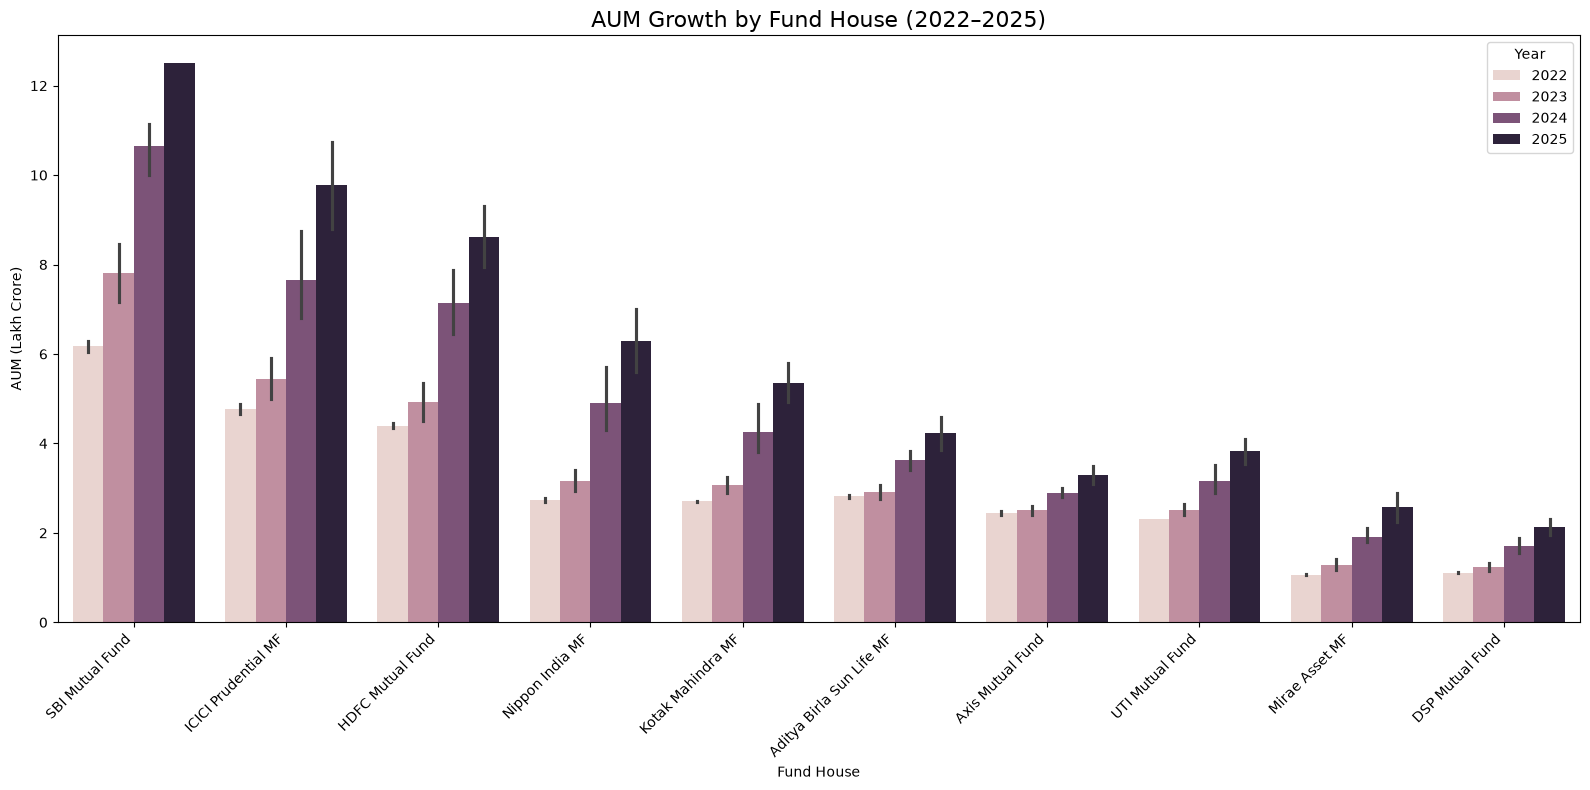

In [10]:
# Plot AUM Growth by Fund House

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)

plt.xlabel("Fund House")

plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Year")

plt.tight_layout()

plt.show()

In [11]:
# Highest AUM

highest = aum.loc[aum["aum_lakh_crore"].idxmax()]

highest

date              2025-03-31 00:00:00
fund_house            SBI Mutual Fund
aum_lakh_crore                   12.5
aum_crore                     1250000
num_schemes                       186
year                             2025
Name: 70, dtype: object

### Observation

- SBI Mutual Fund recorded the highest Assets Under Management among the selected fund houses.
- Most fund houses showed a gradual increase in AUM between 2022 and 2025.
- HDFC and ICICI Prudential Mutual Fund also maintained strong AUM growth during the analysis period.

## SIP Inflow Trend Analysis

This section analyzes the monthly SIP inflows from January 2022 to December 2025. The trend helps understand the growth of systematic investments over the years and highlights the highest monthly SIP inflow.

In [12]:
# Convert month column into datetime format

sip["month"] = pd.to_datetime(sip["month"])

# Check the data

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [13]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow (Jan 2022 - Dec 2025)"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore ₹)"
)

fig.show()

In [16]:
highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text="Highest SIP: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()

### Observation

- SIP inflows increased steadily between 2022 and 2025.
- The highest monthly SIP inflow was recorded in December 2025 at approximately ₹31,002 crore.
- The consistent increase indicates growing investor participation in mutual fund SIPs.

## Category-wise Net Inflow Analysis

This section shows how net inflows changed across different mutual fund categories over time. A heatmap helps identify which categories received higher investments during different months.

In [17]:
# Convert month column into datetime format

category["month"] = pd.to_datetime(category["month"])

# Create Month-Year column

category["Month"] = category["month"].dt.strftime("%b-%Y")

category.head()

,month,category,net_inflow_crore,Month
0,2024-04-01,Large Cap,2413.0,Apr-2024
1,2024-04-01,Mid Cap,3897.0,Apr-2024
2,2024-04-01,Small Cap,3533.0,Apr-2024
3,2024-04-01,Flexi Cap,4947.0,Apr-2024
4,2024-04-01,Large & Mid Cap,4214.0,Apr-2024


In [18]:
# Create Pivot Table

heatmap_data = category.pivot(
    index="category",
    columns="Month",
    values="net_inflow_crore"
)

heatmap_data.head()

Month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


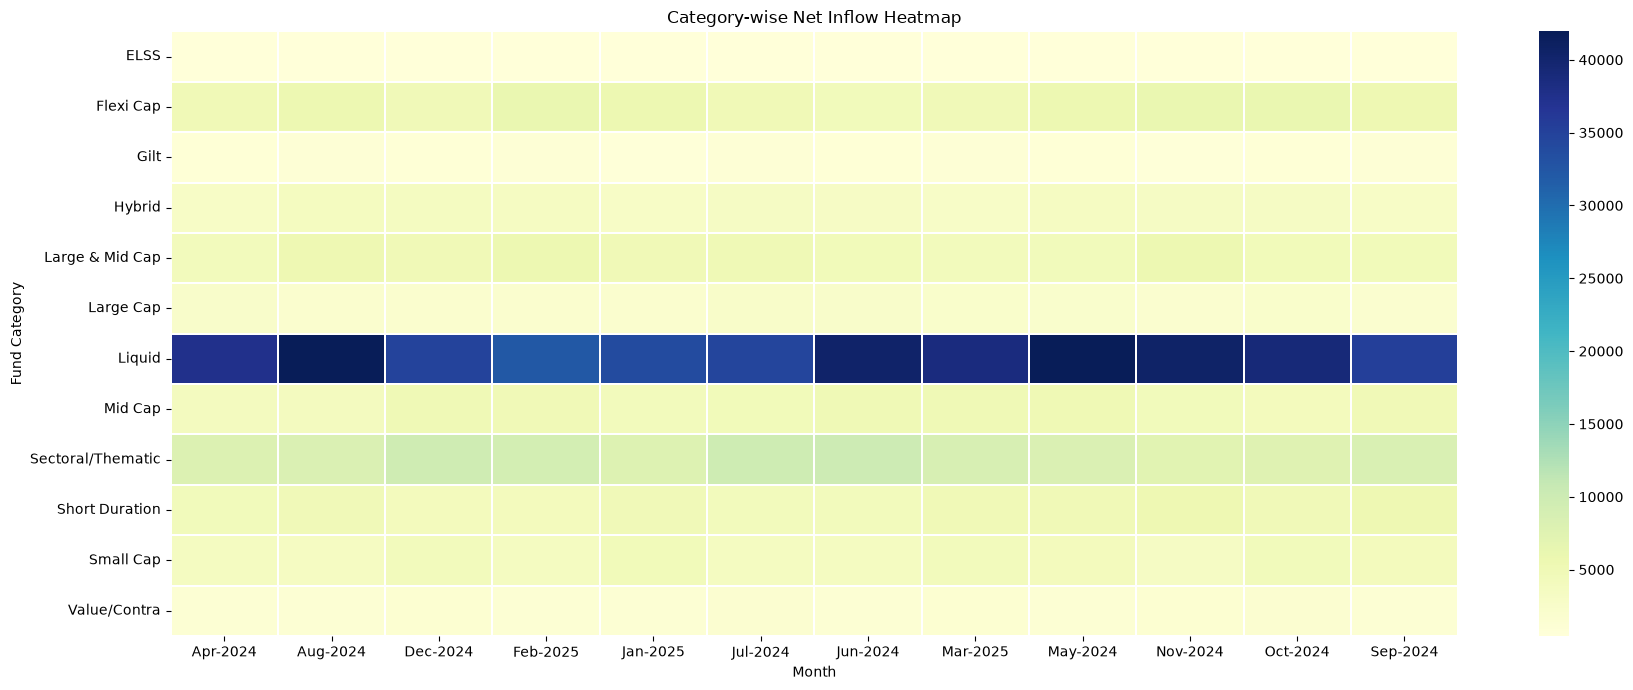

In [19]:
plt.figure(figsize=(18,7))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.3
)

plt.title("Category-wise Net Inflow Heatmap")

plt.xlabel("Month")

plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

### Observation

- Equity-oriented categories received higher inflows during most months.
- Some categories experienced lower or negative inflows during market corrections.
- The heatmap clearly shows changing investor preferences across different mutual fund categories.

## Investor Demographics Analysis

This section analyzes the demographic profile of mutual fund investors. It includes age group distribution, investment amount across different age groups, and gender-wise participation.

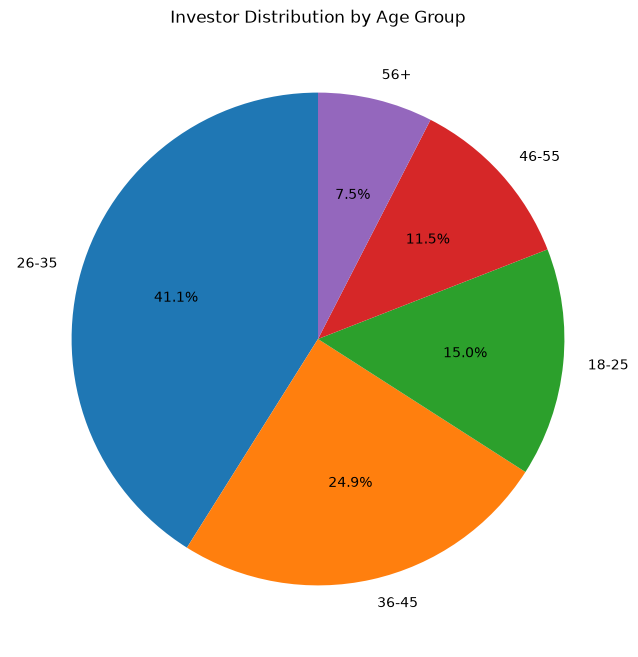

In [20]:
plt.figure(figsize=(8,8))

age_counts = transactions["age_group"].value_counts()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.show()

### Observation

- Most investors belong to the middle age groups.
- Younger and senior investors represent a smaller share of total investors.

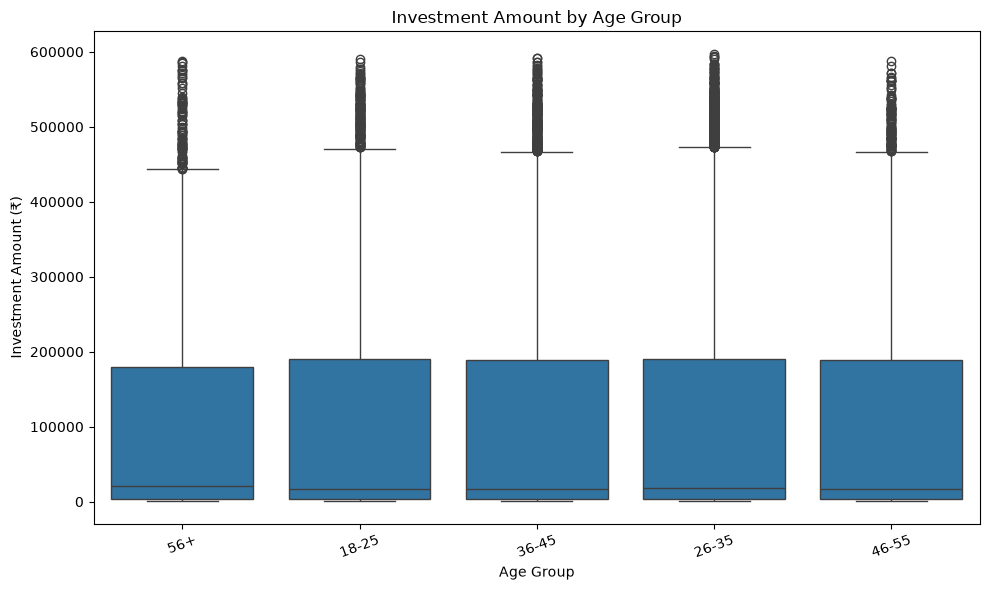

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

### Observation

- Investment amounts vary across age groups.
- Some age groups show a wider spread, indicating both small and large investments.

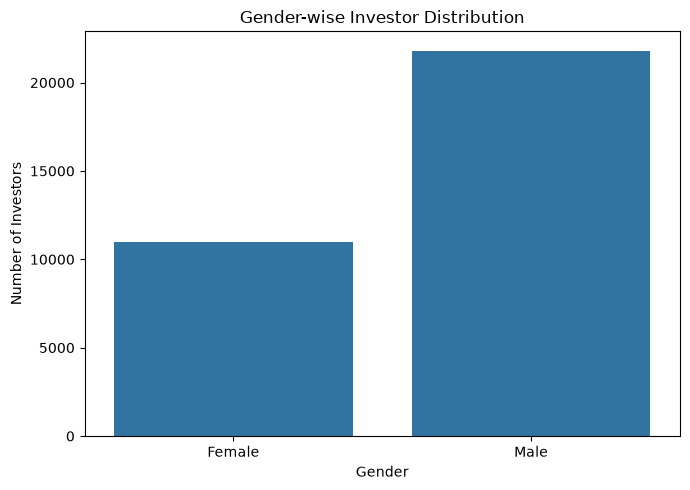

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender-wise Investor Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Investors")

plt.tight_layout()

plt.show()

### Observation

- The dataset includes participation from both male and female investors.
- The chart shows the overall gender distribution of investors in the dataset.

## Geographic Distribution Analysis

This section analyzes investment patterns across different states and city tiers. It helps identify regions contributing higher investment amounts and compares investments from T30 and B30 cities.

In [23]:
# Total investment amount by state

state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_amount.head()

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64

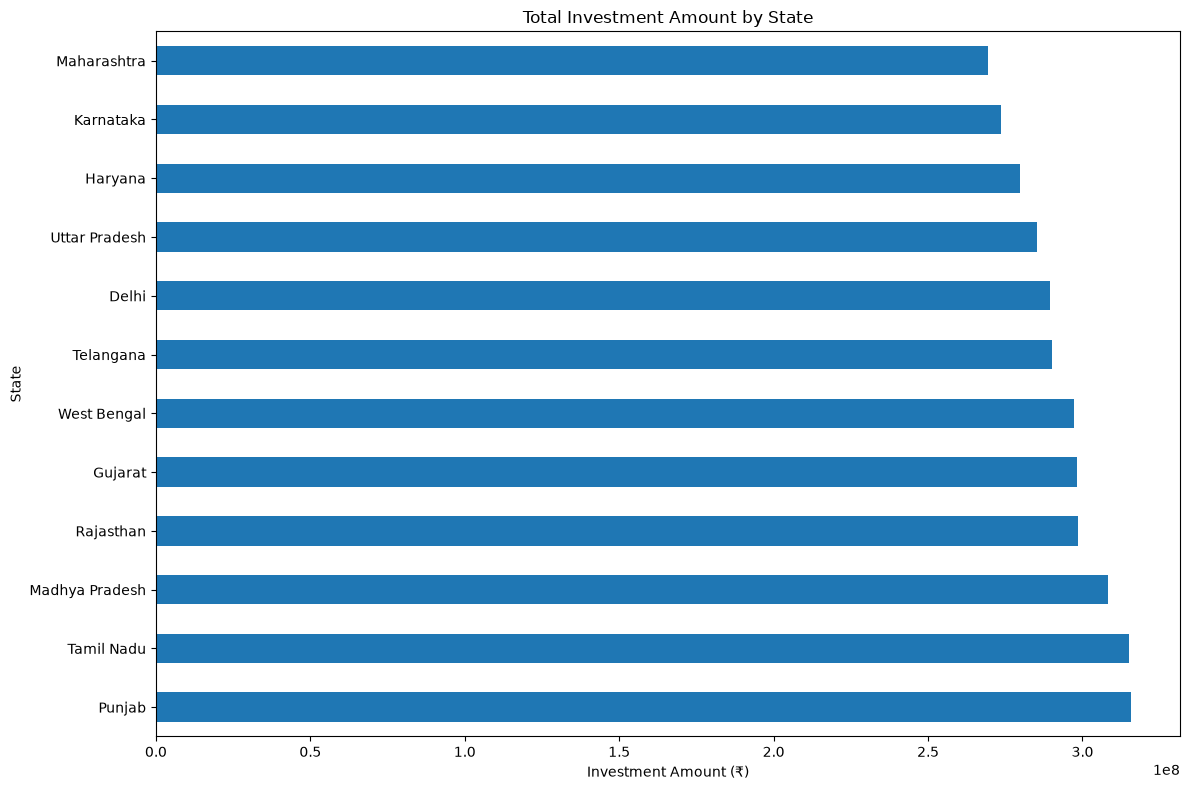

In [24]:
plt.figure(figsize=(12,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")

plt.xlabel("Investment Amount (₹)")

plt.ylabel("State")

plt.tight_layout()

plt.show()

### Observation

- A few states contribute a major share of the total investment amount.
- The remaining states have comparatively lower investment participation.

In [25]:
city_counts = transactions["city_tier"].value_counts()

city_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

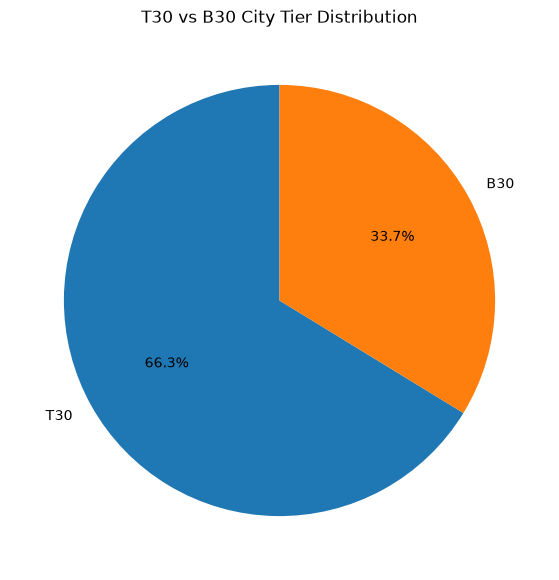

In [26]:
plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.show()

### Observation

- T30 cities account for a significant share of investors.
- B30 cities also contribute meaningfully, showing increasing mutual fund adoption beyond major metropolitan areas.

## Folio Count Growth Analysis

This section shows the growth in mutual fund folios from 2022 to 2025. It helps understand how the number of investors has increased over time.

In [28]:
# Convert month column into datetime format

folio["month"] = pd.to_datetime(folio["month"])

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [30]:
import plotly.express as px

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth in Mutual Fund Folios (2022–2025)"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.show()

In [31]:
fig.add_annotation(
    x=folio.iloc[0]["month"],
    y=folio.iloc[0]["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=folio.iloc[-1]["month"],
    y=folio.iloc[-1]["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True
)

fig.show()

### Observation

- The total number of mutual fund folios increased steadily between 2022 and 2025.
- The folio count grew from around 13.26 crore to 26.12 crore during the study period.
- This reflects increasing investor participation in mutual funds.

## NAV Return Correlation Analysis

This section compares the daily NAV returns of selected mutual fund schemes. A correlation matrix helps understand whether different schemes move together or behave differently over time.

In [32]:
# Select first 10 schemes

selected_funds = fund_master["amfi_code"].head(10)

selected_nav = nav_data[
    nav_data["amfi_code"].isin(selected_funds)
]

selected_nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [33]:
# Create pivot table

pivot_nav = selected_nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

pivot_nav.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-03,117.5969,107.3758,26.3169,560.1443,520.4608,58.4174,54.3856,42.1391,96.4565,89.8738
2022-01-04,117.0077,105.9447,26.2234,560.7052,515.0971,57.3480,54.3474,42.2508,94.6512,88.5495
2022-01-05,116.4011,105.4800,26.2221,563.0884,521.7239,57.0552,54.6869,42.4374,94.5436,88.0925
2022-01-06,116.0861,104.9350,26.1728,561.0675,515.7880,56.4224,55.4550,42.5901,93.7944,88.5175
2022-01-07,114.6164,104.3318,26.2261,559.5420,515.1639,57.2750,55.3692,42.4851,89.6438,91.4235


In [34]:
# Calculate daily percentage returns

daily_returns = pivot_nav.pct_change()

daily_returns.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.005010,-0.013328,-0.003553,0.001001,-0.010306,-0.018306,-0.000702,0.002651,-0.018716,-0.014735
2022-01-05,-0.005184,-0.004386,-0.000050,0.004250,0.012865,-0.005106,0.006247,0.004416,-0.001137,-0.005161
2022-01-06,-0.002706,-0.005167,-0.001880,-0.003589,-0.011377,-0.011091,0.014045,0.003598,-0.007924,0.004824
2022-01-07,-0.012660,-0.005748,0.002036,-0.002719,-0.001210,0.015111,-0.001547,-0.002465,-0.044252,0.032830


In [35]:
# Correlation Matrix

correlation = daily_returns.corr()

correlation.head()

scheme_name,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Direct Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth,SBI Bluechip Fund - Direct Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Small Cap Fund - Direct Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
scheme_name,,,,,,,,,,
HDFC Mid-Cap Opportunities Fund - Direct - Growth,1.000000,-0.011916,-0.025505,0.027394,-0.016089,-0.052299,0.030454,-0.016315,0.041927,0.018443
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.011916,1.000000,0.002150,-0.025137,-0.000006,-0.027471,-0.015559,-0.007166,-0.028323,0.006659
HDFC Short Term Debt Fund - Regular - Growth,-0.025505,0.002150,1.000000,0.011326,0.045567,-0.002803,0.017017,-0.040884,-0.034061,-0.065019
HDFC Top 100 Fund - Direct Plan - Growth,0.027394,-0.025137,0.011326,1.000000,0.047139,0.027796,0.016469,-0.010542,0.003347,-0.053278
HDFC Top 100 Fund - Regular Plan - Growth,-0.016089,-0.000006,0.045567,0.047139,1.000000,0.013663,0.040858,-0.022521,-0.000007,-0.030296


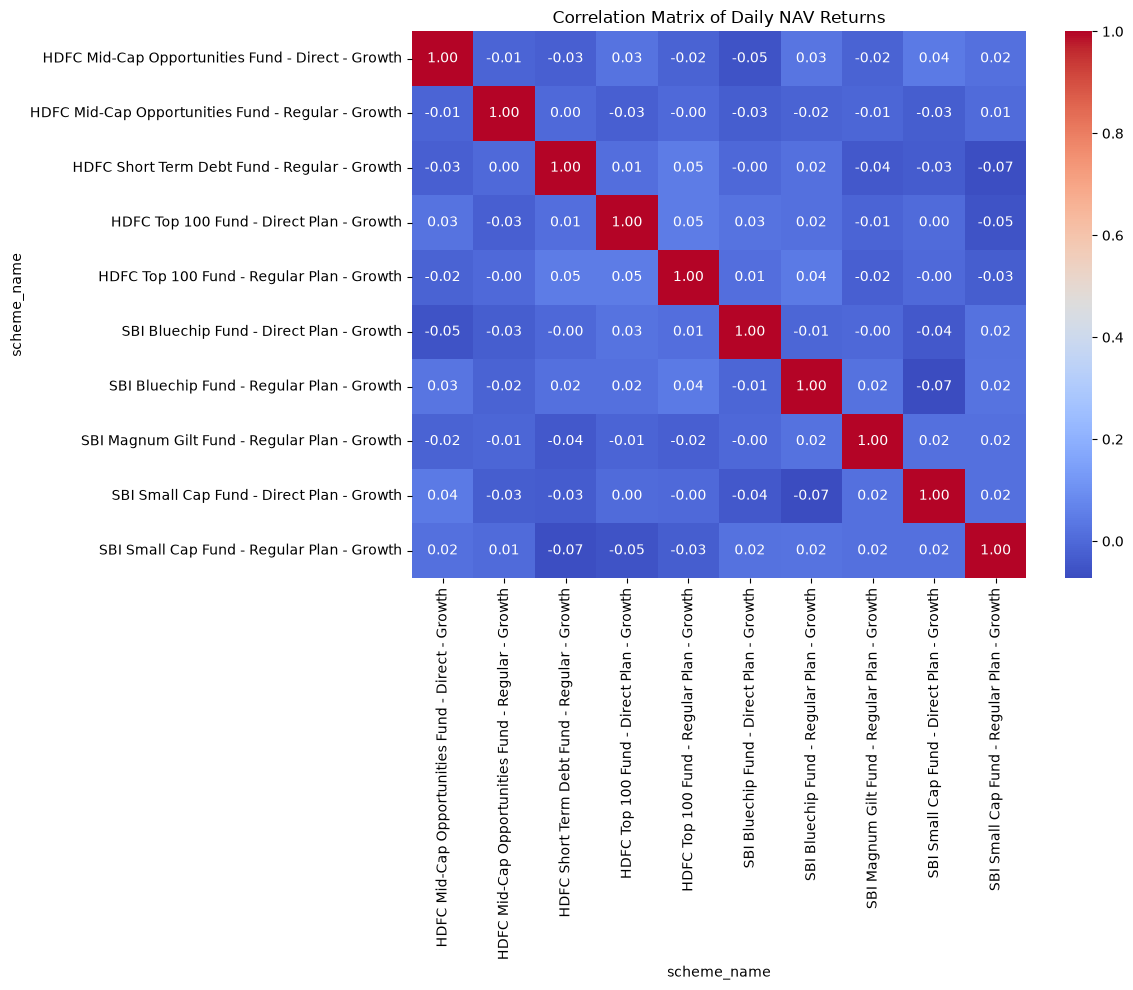

In [36]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.show()

### Observation

- Most selected schemes show a positive correlation in daily NAV returns.
- A few schemes have stronger relationships, indicating similar market movement.
- Lower correlation values suggest diversification benefits across different schemes.

## Sector Allocation Analysis

This section analyzes the sector-wise allocation of mutual fund portfolios. The donut chart shows the overall distribution of investments across different sectors.

In [39]:
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

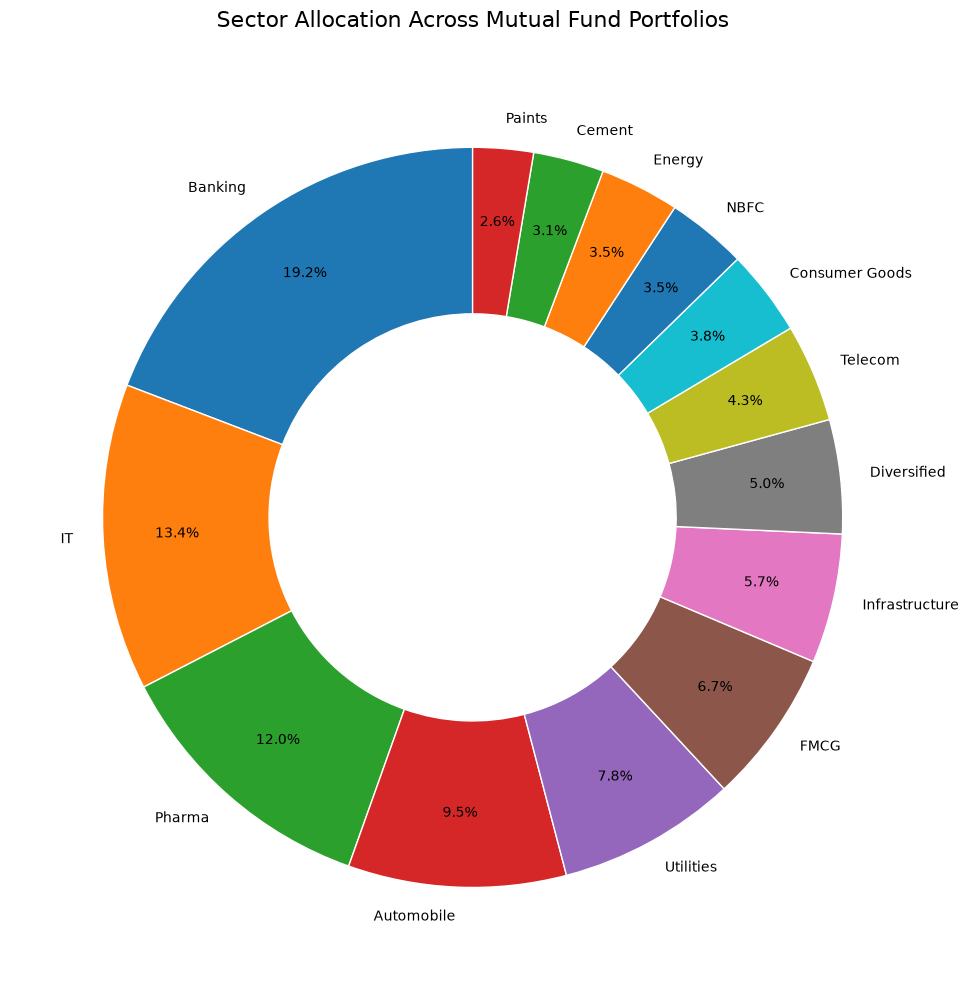

In [49]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.80,
    labeldistance=1.08,
    wedgeprops=dict(width=0.45, edgecolor="white")
)

plt.title(
    "Sector Allocation Across Mutual Fund Portfolios",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.show()

### Observation

- Banking sector has the highest allocation across the mutual fund portfolios.
- IT and Pharma are also major sectors with significant portfolio weight.
- The allocation is spread across multiple sectors, indicating diversification.

## Additional Visualizations

The following charts provide additional insights into investor behavior and mutual fund performance.

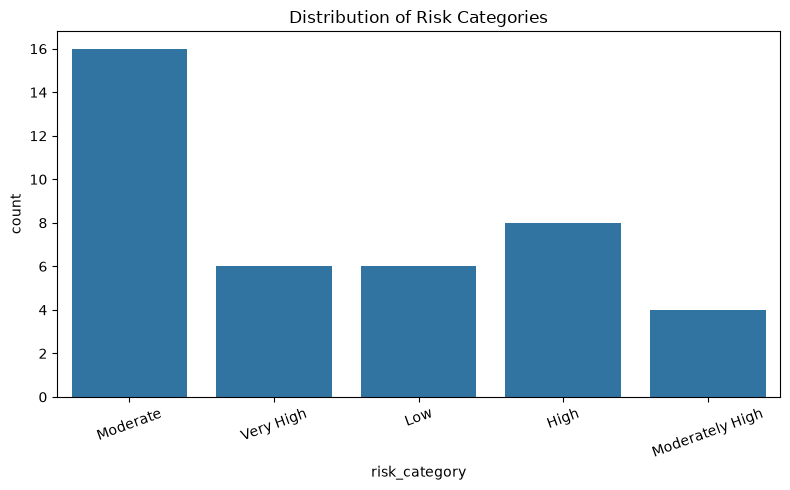

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fund_master,
    x="risk_category"
)

plt.title("Distribution of Risk Categories")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

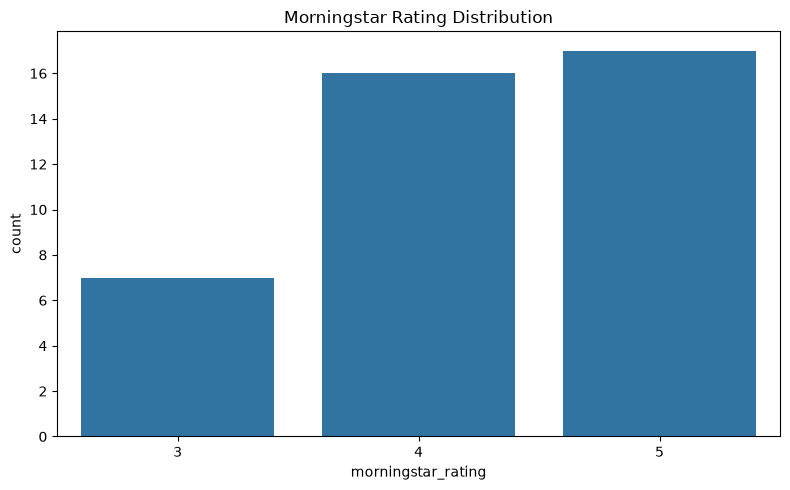

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.tight_layout()

plt.show()

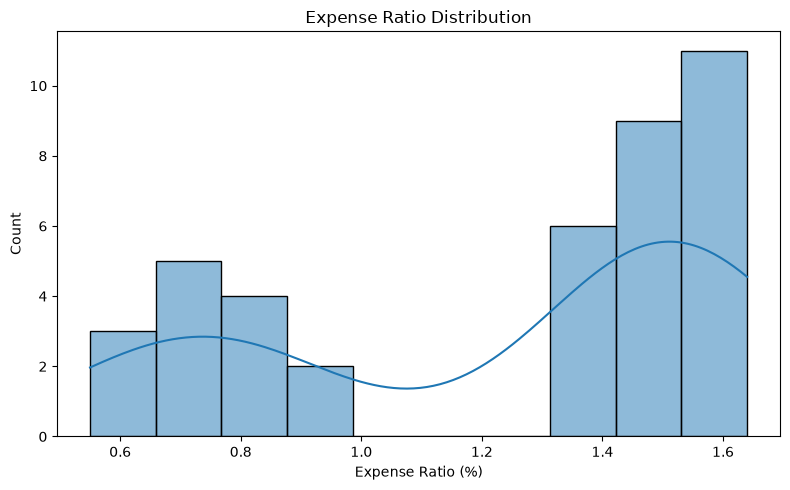

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

plt.show()

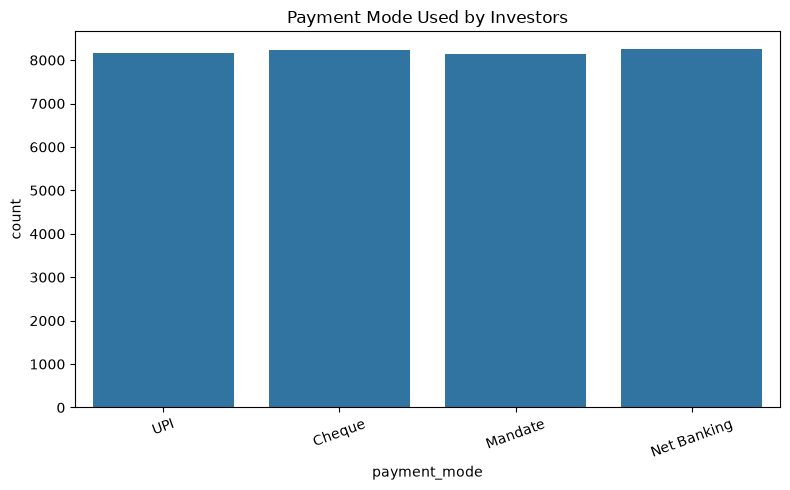

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="payment_mode"
)

plt.title("Payment Mode Used by Investors")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

### Observation

- Most funds belong to moderate and high-risk categories.
- Morningstar ratings indicate a good distribution of fund quality.
- Expense ratios are concentrated within the expected range.
- Digital payment modes are widely used by investors.

# Key EDA Findings

1. Daily NAV values showed consistent long-term growth across most schemes (NAV Trend Analysis).

2. AUM increased steadily between 2022 and 2025 for all major fund houses (AUM Growth Chart).

3. SBI Mutual Fund maintained the highest AUM among the analyzed fund houses (AUM Growth Chart).

4. Monthly SIP inflows increased significantly and reached their highest value in December 2025 (SIP Trend).

5. Equity-oriented categories attracted higher net inflows than most other categories (Category Heatmap).

6. Middle-aged investors represented the largest share of mutual fund investors (Age Group Distribution).

7. Investment amounts varied across different age groups (Box Plot).

8. Mutual fund folios increased steadily from 2022 to 2025, indicating growing investor participation (Folio Growth Chart).

9. Most selected mutual fund schemes showed positive correlation in daily NAV returns (Correlation Matrix).

10. Portfolio holdings were diversified across multiple sectors, reducing concentration risk (Sector Allocation Donut Chart).